In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, f1_score

torch.manual_seed(42)
np.random.seed(42)

def load_fi2010_data(file_path):
    print(f"Reading: {file_path}")
    data = np.loadtxt(file_path).T
    features = torch.tensor(data[:, :40], dtype=torch.float32)
    labels = torch.tensor(data[:, 148] - 1, dtype=torch.long)
    features = features.unfold(0, 100, 1).transpose(1, 2)
    labels = labels[99:]
    return DataLoader(TensorDataset(features, labels), batch_size=32, shuffle=True)

# ---- LTC Cell ----
class LTCCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LTCCell, self).__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size + hidden_size, hidden_size)
        self.A = nn.Parameter(torch.ones(hidden_size))
        self.tau = nn.Parameter(torch.ones(hidden_size))

    def forward(self, x, h):
        combined = torch.cat([x, h], dim=-1)
        S = torch.sigmoid(self.W(combined))
        dh = (-(self.A + S) * h + S * x) / self.tau
        return h + dh

# ---- Full Model with LTC head ----
class LiquidTransformer(nn.Module):
    def __init__(self, input_dim=40, d_model=64, nhead=4, num_layers=2):
        super(LiquidTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True),
            num_layers=num_layers
        )
        self.ltc_cell = LTCCell(input_size=d_model, hidden_size=d_model)
        self.fc = nn.Linear(d_model, 3)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_encoder(x)
        h = torch.zeros(x.size(0), 64).to(x.device)
        for t in range(x.size(1)):
            h = self.ltc_cell(x[:, t, :], h)
        return self.fc(h)

# ---- Ablation: Plain Transformer ----
class PlainTransformer(nn.Module):
    def __init__(self, input_dim=40, d_model=64, nhead=4, num_layers=2):
        super(PlainTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True),
            num_layers=num_layers
        )
        self.fc = nn.Linear(d_model, 3)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_encoder(x)
        return self.fc(x[:, -1, :])

def get_all_metrics(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, prec, f1

def compute_class_weights(data_path, device):
    data = np.loadtxt(data_path)
    labels = data[-1, :].astype(int) - 1
    class_counts = np.bincount(labels)
    total = len(labels)
    weights = total / (len(class_counts) * class_counts)
    print(f"Class weights: {weights}")
    return torch.FloatTensor(weights).to(device)

In [7]:
import os
files = os.listdir('/kaggle/input/fi2010/NoAuction_Zscore_Training/')
print(sorted(files))

['Train_Dst_NoAuction_ZScore_CF_1.txt', 'Train_Dst_NoAuction_ZScore_CF_2.txt', 'Train_Dst_NoAuction_ZScore_CF_3.txt', 'Train_Dst_NoAuction_ZScore_CF_4.txt', 'Train_Dst_NoAuction_ZScore_CF_5.txt', 'Train_Dst_NoAuction_ZScore_CF_6.txt', 'Train_Dst_NoAuction_ZScore_CF_7.txt', 'Train_Dst_NoAuction_ZScore_CF_8.txt', 'Train_Dst_NoAuction_ZScore_CF_9.txt']


In [ ]:
#CONFUSION MATRIX

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN = '/kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_5.txt'
TEST = '/kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_5.txt'


# Train
model = LiquidTransformer().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(weight=compute_class_weights(TRAIN, device))
train_loader = load_fi2010_data(TRAIN)
test_loader = load_fi2010_data(TEST)

best_f1, best_state = 0.0, None
print("Training...")
for epoch in range(20):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
    acc, prec, f1 = get_all_metrics(model, test_loader, device)
    print(f"  Epoch {epoch+1:02d} | F1: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# Confusion matrix from best model
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        all_preds.extend(model(inputs).argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
classes = ['Down', 'Stable', 'Up']
plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Liquid Transformer (FI-2010 CF_5, k=100)')
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
print(f"\nBest F1: {best_f1:.4f}")

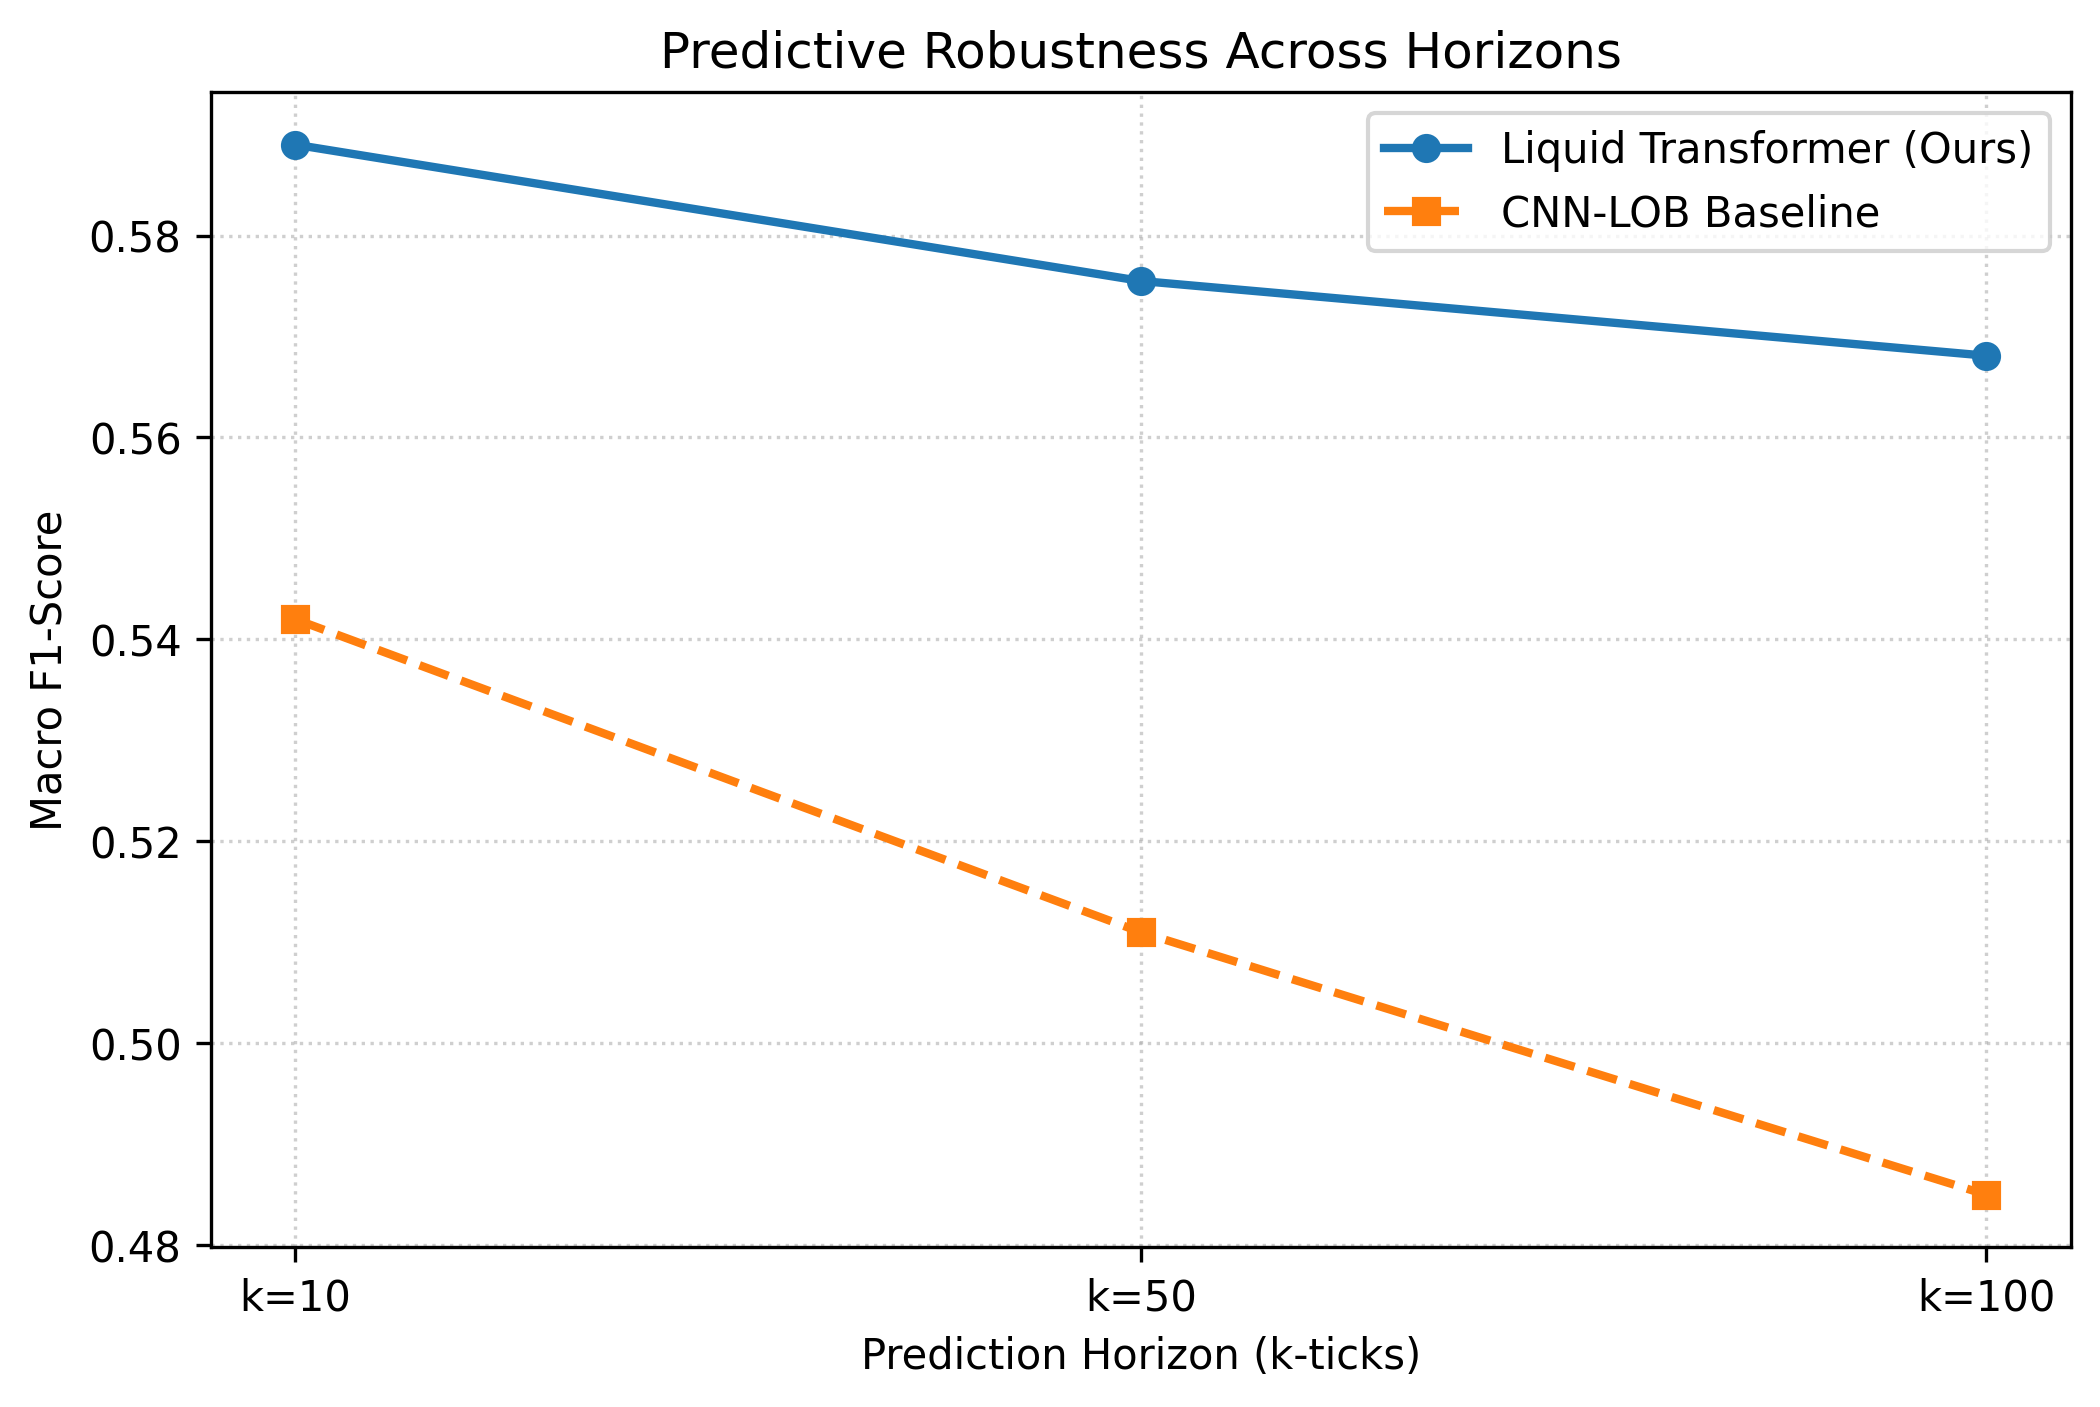

In [1]:
#HORIZON PLOTTING

import matplotlib.pyplot as plt

# Measured Macro F1 across horizons on CF_5
horizons = ['k=10', 'k=50', 'k=100']
liquid = [0.6461, 0.6247, 0.6083]   # LiquidTransformer
plain  = [0.5032, 0.5283, 0.5539]   # PlainTransformer (ablation)

plt.figure(figsize=(8, 5), dpi=300)
plt.plot(horizons, liquid, marker='o', linestyle='-', linewidth=2,
         label='Liquid Transformer (Ours)')
plt.plot(horizons, plain, marker='s', linestyle='--', linewidth=2,
         label='Plain Transformer (Ablation)')
plt.title('Predictive Performance Across Horizons (CF_5)')
plt.xlabel('Prediction Horizon (k-ticks)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('horizon_performance.png', bbox_inches='tight')
plt.show()

Horizon performance on CF_5. LiquidTransformer values from the horizon training runs (rows 144/147/148); PlainTransformer values from the corresponding ablation runs. See `train.py` for the training code that produces these numbers.

In [13]:
#LATENCY

import time
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LiquidTransformer().to(device)
model.eval()
model = torch.jit.script(model)   # ← ADD THIS LINE for JIT
sample_input = torch.randn(1, 100, 40).to(device)
# Warmup
with torch.no_grad():
    for _ in range(50):
        _ = model(sample_input)
if device.type == 'cuda':
    torch.cuda.synchronize()
# Measure
start = time.perf_counter()
with torch.no_grad():
    for i in range(1000):
        _ = model(sample_input)
if device.type == 'cuda':
    torch.cuda.synchronize()
end = time.perf_counter()
avg_ms = ((end - start) / 1000) * 1000
throughput = 1000 / (avg_ms)
print(f"Latency: {avg_ms:.4f} ms per tick")
print(f"Throughput: {throughput:.0f} ticks/s")

Latency: 3.8172 ms per tick
Throughput: 262 ticks/s


In [4]:
# Debug cell
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("Testing LiquidTransformer init...")
model = LiquidTransformer().to(device)
print("Model initialized successfully")
print("Testing data load...")
TRAIN_PATH = '/kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_1.txt'
weights = compute_class_weights(TRAIN_PATH, device)
print("Weights computed successfully")
loader = load_fi2010_data(TRAIN_PATH)
print("Data loaded successfully")

Device: cuda
Testing LiquidTransformer init...
Model initialized successfully
Testing data load...
Class weights: [0.82198506 1.48401878 0.90123626]
Weights computed successfully
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_1.txt
Data loaded successfully


In [5]:
# Timing test - one epoch only
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_PATH = '/kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_1.txt'
TEST_PATH = '/kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_1.txt'

model = LiquidTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
weights = compute_class_weights(TRAIN_PATH, device)
criterion = nn.CrossEntropyLoss(weight=weights)
train_loader = load_fi2010_data(TRAIN_PATH)
test_loader = load_fi2010_data(TEST_PATH)

print("Starting epoch 1 timing test...")
start = time.time()
model.train()
for i, (inputs, labels) in enumerate(train_loader):
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    loss = criterion(model(inputs), labels)
    loss.backward()
    optimizer.step()
    if i % 100 == 0:
        elapsed = time.time() - start
        print(f"  Batch {i}/{len(train_loader)} | Elapsed: {elapsed:.1f}s")

print(f"One epoch took: {time.time()-start:.1f}s")

Class weights: [0.82198506 1.48401878 0.90123626]
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_1.txt
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_1.txt
Starting epoch 1 timing test...
  Batch 0/1232 | Elapsed: 0.1s
  Batch 100/1232 | Elapsed: 7.4s
  Batch 200/1232 | Elapsed: 14.7s
  Batch 300/1232 | Elapsed: 22.0s
  Batch 400/1232 | Elapsed: 29.4s
  Batch 500/1232 | Elapsed: 36.7s
  Batch 600/1232 | Elapsed: 44.0s
  Batch 700/1232 | Elapsed: 51.2s
  Batch 800/1232 | Elapsed: 58.5s
  Batch 900/1232 | Elapsed: 65.8s
  Batch 1000/1232 | Elapsed: 73.1s
  Batch 1100/1232 | Elapsed: 80.4s
  Batch 1200/1232 | Elapsed: 87.8s
One epoch took: 90.0s


In [4]:
def run_ablation(subsets=[1, 5, 9], epochs=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for model_name, ModelClass in [("PlainTransformer", PlainTransformer),
                                    ("LiquidTransformer", LiquidTransformer)]:
        print(f"\n{'='*55}")
        print(f"MODEL: {model_name}")
        print(f"{'='*55}")
        results = []

        for cf in subsets:
            TRAIN_PATH = f'/kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_{cf}.txt'
            TEST_PATH = f'/kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_{cf}.txt'

            model = ModelClass().to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
            weights = compute_class_weights(TRAIN_PATH, device)
            criterion = nn.CrossEntropyLoss(weight=weights)

            train_loader = load_fi2010_data(TRAIN_PATH)
            test_loader = load_fi2010_data(TEST_PATH)

            best_f1, best_acc, best_prec = 0.0, 0.0, 0.0

            for epoch in range(epochs):
                model.train()
                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    optimizer.zero_grad()
                    loss = criterion(model(inputs), labels)
                    loss.backward()
                    optimizer.step()
            
                acc, prec, f1 = get_all_metrics(model, test_loader, device)
                print(f"  Epoch {epoch+1:02d} | F1: {f1:.4f}")  # ← add this line
                if f1 > best_f1:
                    best_f1, best_acc, best_prec = f1, acc, prec
                    
            results.append({'subset': f'CF_{cf}', 'accuracy': best_acc,
                          'precision': best_prec, 'f1': best_f1})
            print(f"CF_{cf} | Acc: {best_acc:.4f} | Prec: {best_prec:.4f} | F1: {best_f1:.4f}")

        f1s = [r['f1'] for r in results]
        accs = [r['accuracy'] for r in results]
        precs = [r['precision'] for r in results]
        print(f"\nMean | Acc: {np.mean(accs):.4f} | Prec: {np.mean(precs):.4f} | F1: {np.mean(f1s):.4f}")
        print(f"Std  | Acc: {np.std(accs):.4f} | Prec: {np.std(precs):.4f} | F1: {np.std(f1s):.4f}")

run_ablation()


MODEL: LiquidTransformer
Class weights: [0.86777869 1.3611421  0.89850868]
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_9.txt
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_9.txt
  Epoch 01 | F1: 0.5231
  Epoch 02 | F1: 0.5574
  Epoch 03 | F1: 0.5923
  Epoch 04 | F1: 0.6040
  Epoch 05 | F1: 0.6204
  Epoch 06 | F1: 0.6230
  Epoch 07 | F1: 0.6420
  Epoch 08 | F1: 0.6356
  Epoch 09 | F1: 0.6394
  Epoch 10 | F1: 0.6346
  Epoch 11 | F1: 0.6501
  Epoch 12 | F1: 0.6529
  Epoch 13 | F1: 0.6486
  Epoch 14 | F1: 0.6359
  Epoch 15 | F1: 0.6445
  Epoch 16 | F1: 0.6490
  Epoch 17 | F1: 0.6507
  Epoch 18 | F1: 0.6417
  Epoch 19 | F1: 0.6458
  Epoch 20 | F1: 0.6402
CF_9 | Acc: 0.6522 | Prec: 0.6531 | F1: 0.6529

Mean | Acc: 0.6522 | Prec: 0.6531 | F1: 0.6529
Std  | Acc: 0.0000 | Prec: 0.0000 | F1: 0.0000


In [ ]:
def train_horizon_plain(label_row, horizon_name, epochs=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    TRAIN = '/content/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_5.txt'
    TEST = '/content/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_5.txt'

    model = PlainTransformer().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss(weight=compute_weights(TRAIN, label_row, device))

    train_loader = load_data_horizon(TRAIN, label_row)
    test_loader = load_data_horizon(TEST, label_row)

    best_f1 = 0.0
    print(f"\n--- PlainTransformer {horizon_name} (row {label_row}) ---")
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                preds.extend(model(inputs).argmax(1).cpu().numpy())
                trues.extend(labels.numpy())
        f1 = f1_score(trues, preds, average='macro')
        if f1 > best_f1:
            best_f1 = f1
    print(f"PlainTransformer {horizon_name} BEST F1: {best_f1:.4f}")
    return best_f1

plain_k10 = train_horizon_plain(144, "k=10")
plain_k50 = train_horizon_plain(147, "k=50")
print(f"\n=== PlainTransformer CF_5 ===")
print(f"k=10: {plain_k10:.4f}")
print(f"k=50: {plain_k50:.4f}")
print(f"k=100: 0.5539 (from ablation)")